[1] 모듈로딩 및 데이터 준비 <hr>

In [25]:
## [1-1] 모듈 로딩
from tkinter import *
import pandas as pd
import numpy as np

import torch
import torchvision
from ultralytics import YOLO
import cv2
from matplotlib import pyplot as plt

In [26]:
## [1-2] 데이터 준비
import yt_dlp

url = 'https://www.youtube.com/watch?v=gIjrcfxcyoA'

ydl_opts = {"format": "best"}

with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    info = ydl.extract_info(url, download=False) 
    stream_url = info["url"]

cap = cv2.VideoCapture(stream_url)

[youtube] Extracting URL: https://www.youtube.com/watch?v=gIjrcfxcyoA
[youtube] gIjrcfxcyoA: Downloading webpage


[youtube] gIjrcfxcyoA: Downloading android vr player API JSON


[2] YOLO26n VS RTDETR-L <hr>

In [27]:
## [1-1] 모듈 로딩 셀 쪽에 RTDETR 추가 (이미 있다면 생략 가능)
from ultralytics import YOLO, RTDETR 

## 모델 정의
base_model = YOLO("yolo26n.pt")        # 왼쪽: YOLO26 나노 모델
up_model = RTDETR("rtdetr-l.pt")       # 오른쪽: RT-DETR 라지 모델 (또는 rtdetr-x.pt)

## 자동차, 버스, 트럭, 오토바이 클래스 번호 (COCO 데이터셋 기준 맞음!)
# 2: car, 3: motorcycle, 5: bus, 7: truck
target_classes = [2, 3, 5, 7]

In [28]:
import time

# ByteTrack 및 BoT-SORT 활성화용 tracker 설정
tracker_cfg = "bytetrack.yaml"
tracker_bst = "botsort.yaml" # RT-DETR에는 BoT-SORT 적용

# --- 📊 데이터 수집용 변수 추가 ---
yolo_unique_ids = set()
rt_detr_unique_ids = set()

time_log = []
yolo_cumulative_log = []
rtdetr_cumulative_log = []

start_time = time.time()
frame_count = 0

# 영상의 FPS 가져오기 (만약 0으로 나오면 기본값 30 적용)
fps_target = int(cap.get(cv2.CAP_PROP_FPS))
if fps_target == 0: 
    fps_target = 30 
# -----------------------------------

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    frame_det = frame.copy()
    frame_track = frame.copy()

    # ============================
    # 1️⃣ Detection 전용 (왼쪽: YOLO26 + ByteTrack)
    # ============================
    results_det = base_model.track(
        frame_det, conf=0.5, tracker=tracker_cfg, persist=True, verbose=False
    )

    # 화면에 박스 그리기 및 데이터 수집
    if results_det[0].boxes is not None and results_det[0].boxes.id is not None:
        for box, track_id in zip(results_det[0].boxes, results_det[0].boxes.id.int().tolist()):
            cls_id = int(box.cls[0])
            if cls_id in target_classes:
                yolo_unique_ids.add(track_id) # 고유 ID 저장
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                conf = float(box.conf[0])

                cv2.rectangle(frame_det, (x1,y1), (x2,y2), (0,0,255), 2)
                cv2.putText(frame_det, f"ID:{track_id} {base_model.names[cls_id]} {conf:.2f}",
                            (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,255), 2)

    cv2.putText(frame_det, "YOLOv26 + Bytetrack", (20,40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

    # ============================
    # 2️⃣ Detection + BoT-SORT (오른쪽: RT-DETR + BoT-SORT)
    # ============================
    results_track = up_model.track(
        frame_track, conf=0.5, tracker=tracker_bst, persist=True, verbose=False
    )

    # 화면에 박스 그리기 및 데이터 수집
    if results_track[0].boxes is not None and results_track[0].boxes.id is not None:
        for box, track_id in zip(results_track[0].boxes, results_track[0].boxes.id.int().tolist()):
            cls_id = int(box.cls[0])
            if cls_id in target_classes:
                rt_detr_unique_ids.add(track_id) # 고유 ID 저장
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                conf = float(box.conf[0])

                cv2.rectangle(frame_track, (x1,y1), (x2,y2), (0,0,255), 2)
                cv2.putText(frame_track, f"ID:{track_id} {up_model.names[cls_id]} {conf:.2f}",
                            (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,255), 2)

    cv2.putText(frame_track, "RT-DETR + BoT-SORT", (20,40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 2)

    # ============================
    # 3️⃣ 1초 단위 기록 및 화면 출력
    # ============================
    if frame_count % fps_target == 0:
        current_time = int(frame_count / fps_target)
        time_log.append(current_time)
        yolo_cumulative_log.append(len(yolo_unique_ids))
        rtdetr_cumulative_log.append(len(rt_detr_unique_ids))

    combined = np.hstack((frame_det, frame_track))
    cv2.imshow("Tracking Comparison", combined)

    if cv2.waitKey(1) & 0xFF == 27: # ESC
        break

cap.release()
cv2.destroyAllWindows()

LinAlgError: 1-th leading minor of the array is not positive definite

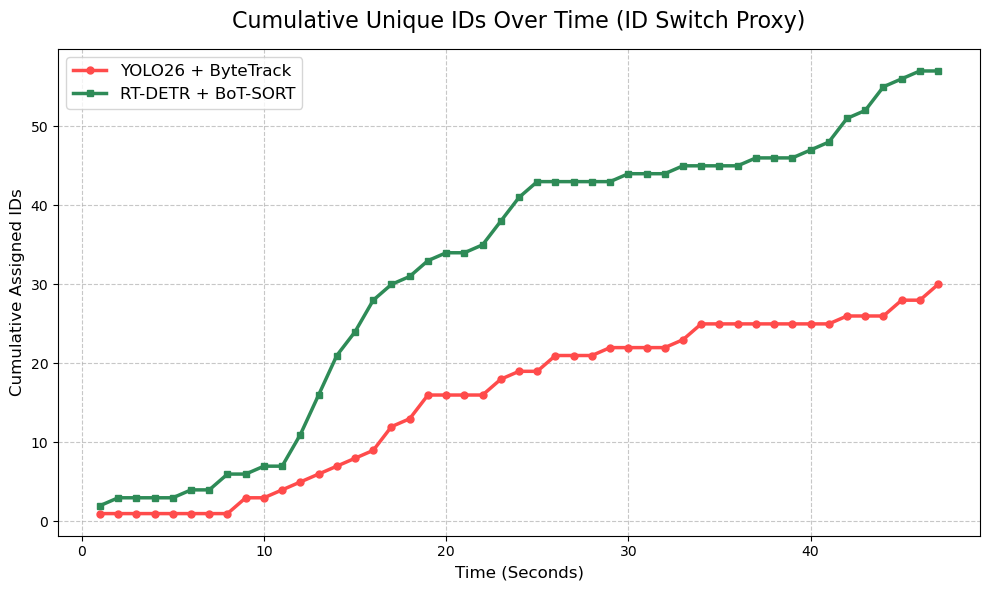

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# YOLO26 + ByteTrack (빨간색)
plt.plot(time_log, yolo_cumulative_log, 
         label='YOLO26 + ByteTrack', color='#FF4B4B', 
         linewidth=2.5, marker='o', markersize=5)
         
# RT-DETR + BoT-SORT (초록색)
plt.plot(time_log, rtdetr_cumulative_log, 
         label='RT-DETR + BoT-SORT', color='#2E8B57', 
         linewidth=2.5, marker='s', markersize=5)

plt.title("Cumulative Unique IDs Over Time (ID Switch Proxy)", fontsize=16, pad=15)
plt.xlabel("Time (Seconds)", fontsize=12)
plt.ylabel("Cumulative Assigned IDs", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12, loc='upper left')
plt.tight_layout()

# 그래프를 이미지 파일로 저장
plt.savefig("id_switching_comparison_botsort.png", dpi=300)
plt.show()

결론 : 그래프만 보면 RT가 안 좋은거 같지만, 멀리 있는 작은 자동차까지 다 잡아서 그렇다 더 길게 보면은 RT가 더 좋을 것이다 (실제로 그랬다)

[3] YOLO26_ByteTrack vs RTDETR_ByteTrack

눈 : YOLO26x

뇌 : ByteTrack

시간 : 5분


In [5]:
import cv2
import yt_dlp
import time
import torch
import json
import os
from ultralytics import YOLO, RTDETR

# --- 설정 영역 ---
MODEL_TYPE = "YOLO"      # "YOLO" 또는 "RT-DETR"
MODEL_PATH = "yolo26x.pt" # "yolo26x.pt" 또는 "rtdetr-l.pt"
TRACKER = "bytetrack.yaml"
LIMIT_SECONDS = 300      # 🎯 자동 종료 시간 설정 (5분 = 300초)

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

# [1-2] 유튜브 데이터 준비
url = 'https://www.youtube.com/watch?v=gIjrcfxcyoA'
ydl_opts = {"format": "best"}
with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    info = ydl.extract_info(url, download=False) 
    stream_url = info["url"]

cap = cv2.VideoCapture(stream_url)

if "rtdetr" in MODEL_PATH:
    model = RTDETR(MODEL_PATH)
else:
    model = YOLO(MODEL_PATH)

all_ids = set()
cumulative_counts = []
timestamps = []
start_time = time.time()

print(f"🚀 {MODEL_TYPE} 추론 시작... ({LIMIT_SECONDS}초 후 자동 종료)")

try:
    while cap.isOpened():
        # ⏱️ 시간 체크: 현재 경과 시간이 설정한 제한 시간을 넘었는지 확인
        elapsed_time = time.time() - start_time
        if elapsed_time > LIMIT_SECONDS:
            print(f"\n⏰ 설정한 시간({LIMIT_SECONDS}초)이 경과되어 자동으로 종료합니다.")
            break
            
        ret, frame = cap.read()
        if not ret: break
        
        results = model.track(
            frame, 
            tracker=TRACKER, 
            device=device, 
            half=True, 
            persist=True, 
            classes=[2, 3, 5, 7], 
            verbose=False
        )
        
        if results[0].boxes.id is not None:
            current_ids = results[0].boxes.id.cpu().numpy().astype(int)
            for obj_id in current_ids:
                all_ids.add(obj_id)
        
        cumulative_counts.append(len(all_ids))
        timestamps.append(elapsed_time)
        
        if len(timestamps) % 100 == 0:
            print(f"[{MODEL_TYPE}] 진행 중... ({elapsed_time:.1f}s / {LIMIT_SECONDS}s) | 누적 ID: {len(all_ids)}")

except KeyboardInterrupt:
    print("\n🛑 사용자가 중단했습니다.")

cap.release()
cv2.destroyAllWindows()

# 💾 결과 저장
history_file = "tracking_history.json"
h_data = {}
if os.path.exists(history_file):
    with open(history_file, "r") as f:
        try: h_data = json.load(f)
        except: h_data = {}

h_data[MODEL_TYPE] = {"time": timestamps, "count": cumulative_counts}
with open(history_file, "w") as f:
    json.dump(h_data, f)

print(f"✅ {MODEL_TYPE} 5분 측정 완료! 데이터가 저장되었습니다.")

[youtube] Extracting URL: https://www.youtube.com/watch?v=gIjrcfxcyoA
[youtube] gIjrcfxcyoA: Downloading webpage


[youtube] gIjrcfxcyoA: Downloading android vr player API JSON
🚀 YOLO 추론 시작... (300초 후 자동 종료)
[YOLO] 진행 중... (1.9s / 300s) | 누적 ID: 2
[YOLO] 진행 중... (3.1s / 300s) | 누적 ID: 3
[YOLO] 진행 중... (4.4s / 300s) | 누적 ID: 9
[YOLO] 진행 중... (5.7s / 300s) | 누적 ID: 17
[YOLO] 진행 중... (7.0s / 300s) | 누적 ID: 28
[YOLO] 진행 중... (8.3s / 300s) | 누적 ID: 36
[YOLO] 진행 중... (9.6s / 300s) | 누적 ID: 45
[YOLO] 진행 중... (10.9s / 300s) | 누적 ID: 47
[YOLO] 진행 중... (12.1s / 300s) | 누적 ID: 51
[YOLO] 진행 중... (13.3s / 300s) | 누적 ID: 56
[YOLO] 진행 중... (14.6s / 300s) | 누적 ID: 57
[YOLO] 진행 중... (15.8s / 300s) | 누적 ID: 62
[YOLO] 진행 중... (17.0s / 300s) | 누적 ID: 69
[YOLO] 진행 중... (18.2s / 300s) | 누적 ID: 76
[YOLO] 진행 중... (19.5s / 300s) | 누적 ID: 78
[YOLO] 진행 중... (20.7s / 300s) | 누적 ID: 81
[YOLO] 진행 중... (21.9s / 300s) | 누적 ID: 86
[YOLO] 진행 중... (23.2s / 300s) | 누적 ID: 95
[YOLO] 진행 중... (24.4s / 300s) | 누적 ID: 98
[YOLO] 진행 중... (25.7s / 300s) | 누적 ID: 100
[YOLO] 진행 중... (26.9s / 300s) | 누적 ID: 101
[YOLO] 진행 중... (28.1s / 300s) | 누

눈 : Rtdetr-l

뇌 : ByteTrack

시간 : 5분


In [6]:
import cv2
import yt_dlp
import time
import torch
import json
import os
from ultralytics import YOLO, RTDETR

# --- 설정 영역 ---
MODEL_TYPE = "RT-DETR"      # "YOLO" 또는 "RT-DETR"
MODEL_PATH = "rtdetr-l.pt" # "yolo26x.pt" 또는 "rtdetr-l.pt"
TRACKER = "bytetrack.yaml"
LIMIT_SECONDS = 300      # 🎯 자동 종료 시간 설정 (5분 = 300초)

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

# [1-2] 유튜브 데이터 준비
url = 'https://www.youtube.com/watch?v=gIjrcfxcyoA'
ydl_opts = {"format": "best"}
with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    info = ydl.extract_info(url, download=False) 
    stream_url = info["url"]

cap = cv2.VideoCapture(stream_url)

if "rtdetr" in MODEL_PATH:
    model = RTDETR(MODEL_PATH)
else:
    model = YOLO(MODEL_PATH)

all_ids = set()
cumulative_counts = []
timestamps = []
start_time = time.time()

print(f"🚀 {MODEL_TYPE} 추론 시작... ({LIMIT_SECONDS}초 후 자동 종료)")

try:
    while cap.isOpened():
        # ⏱️ 시간 체크: 현재 경과 시간이 설정한 제한 시간을 넘었는지 확인
        elapsed_time = time.time() - start_time
        if elapsed_time > LIMIT_SECONDS:
            print(f"\n⏰ 설정한 시간({LIMIT_SECONDS}초)이 경과되어 자동으로 종료합니다.")
            break
            
        ret, frame = cap.read()
        if not ret: break
        
        results = model.track(
            frame, 
            tracker=TRACKER, 
            device=device, 
            half=True, 
            persist=True, 
            classes=[2, 3, 5, 7], 
            verbose=False
        )
        
        if results[0].boxes.id is not None:
            current_ids = results[0].boxes.id.cpu().numpy().astype(int)
            for obj_id in current_ids:
                all_ids.add(obj_id)
        
        cumulative_counts.append(len(all_ids))
        timestamps.append(elapsed_time)
        
        if len(timestamps) % 100 == 0:
            print(f"[{MODEL_TYPE}] 진행 중... ({elapsed_time:.1f}s / {LIMIT_SECONDS}s) | 누적 ID: {len(all_ids)}")

except KeyboardInterrupt:
    print("\n🛑 사용자가 중단했습니다.")

cap.release()
cv2.destroyAllWindows()

# 💾 결과 저장
history_file = "tracking_history.json"
h_data = {}
if os.path.exists(history_file):
    with open(history_file, "r") as f:
        try: h_data = json.load(f)
        except: h_data = {}

h_data[MODEL_TYPE] = {"time": timestamps, "count": cumulative_counts}
with open(history_file, "w") as f:
    json.dump(h_data, f)

print(f"✅ {MODEL_TYPE} 5분 측정 완료! 데이터가 저장되었습니다.")

[youtube] Extracting URL: https://www.youtube.com/watch?v=gIjrcfxcyoA
[youtube] gIjrcfxcyoA: Downloading webpage


[youtube] gIjrcfxcyoA: Downloading android vr player API JSON
🚀 RT-DETR 추론 시작... (300초 후 자동 종료)
[RT-DETR] 진행 중... (4.3s / 300s) | 누적 ID: 13
[RT-DETR] 진행 중... (8.2s / 300s) | 누적 ID: 16
[RT-DETR] 진행 중... (12.3s / 300s) | 누적 ID: 25
[RT-DETR] 진행 중... (16.2s / 300s) | 누적 ID: 51
[RT-DETR] 진행 중... (20.7s / 300s) | 누적 ID: 74
[RT-DETR] 진행 중... (24.7s / 300s) | 누적 ID: 91
[RT-DETR] 진행 중... (28.5s / 300s) | 누적 ID: 105
[RT-DETR] 진행 중... (32.6s / 300s) | 누적 ID: 111
[RT-DETR] 진행 중... (36.3s / 300s) | 누적 ID: 114
[RT-DETR] 진행 중... (40.2s / 300s) | 누적 ID: 123
[RT-DETR] 진행 중... (44.0s / 300s) | 누적 ID: 125
[RT-DETR] 진행 중... (47.8s / 300s) | 누적 ID: 139
[RT-DETR] 진행 중... (51.5s / 300s) | 누적 ID: 153
[RT-DETR] 진행 중... (55.0s / 300s) | 누적 ID: 160
[RT-DETR] 진행 중... (58.8s / 300s) | 누적 ID: 174
[RT-DETR] 진행 중... (62.6s / 300s) | 누적 ID: 183
[RT-DETR] 진행 중... (67.7s / 300s) | 누적 ID: 191
[RT-DETR] 진행 중... (75.1s / 300s) | 누적 ID: 208
[RT-DETR] 진행 중... (83.2s / 300s) | 누적 ID: 220
[RT-DETR] 진행 중... (89.7s / 300s) | 누적 

#rtdetr-x.pt	Extra Large (현재 사용 중)	가장 높은 정확도, 최상급 GPU 권장

#rtdetr-l.pt	Large	성능과 속도의 밸런스형

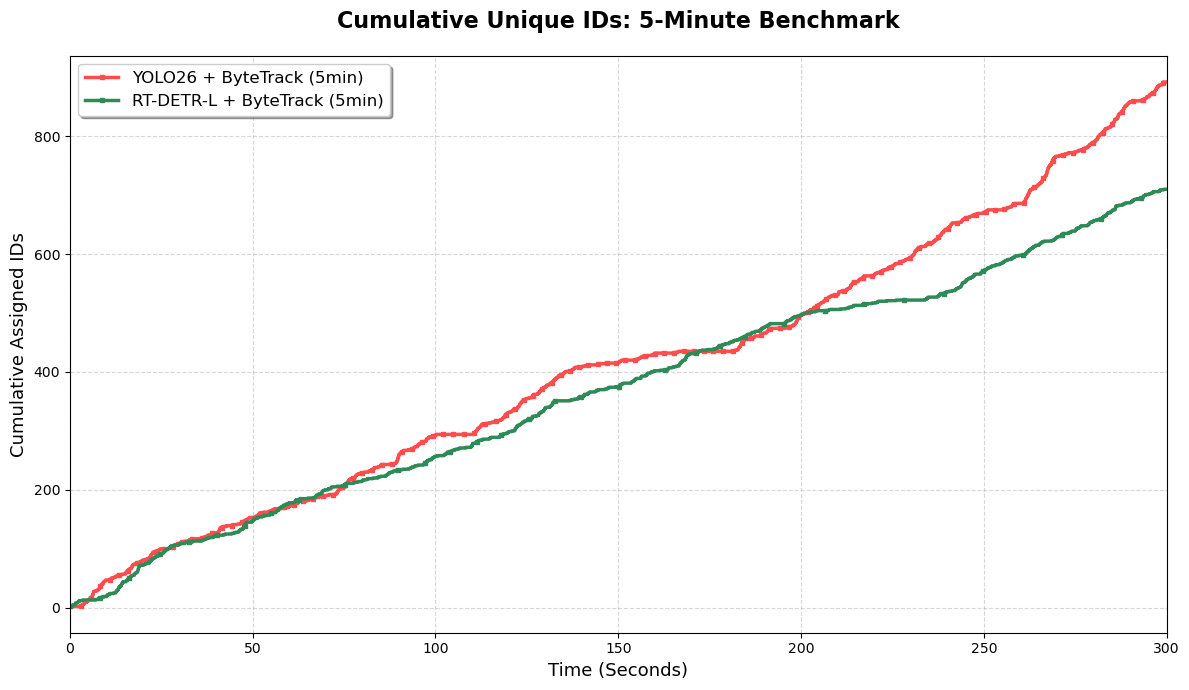

In [7]:
import matplotlib.pyplot as plt
import json
import os

history_file = "tracking_history.json"
if not os.path.exists(history_file):
    print("❌ 데이터 파일이 없습니다. 추론 코드를 먼저 완료해 주세요.")
    exit()

with open(history_file, "r") as f:
    data = json.load(f)

plt.figure(figsize=(12, 7))

# 모델별 색상 및 라벨 설정
config = {
    "YOLO": {"color": "#ff4d4d", "label": "YOLO26 + ByteTrack (5min)"},
    "RT-DETR": {"color": "#2e8b57", "label": "RT-DETR-L + ByteTrack (5min)"}
}

for m_key in data:
    if m_key in config:
        plt.plot(
            data[m_key]["time"], 
            data[m_key]["count"], 
            color=config[m_key]["color"], 
            label=config[m_key]["label"],
            linewidth=2.5, 
            marker='s', 
            markersize=3, 
            markevery=200 # 5분 데이터라 포인트가 많으므로 간격을 넓힘
        )

# 그래프 꾸미기
plt.title('Cumulative Unique IDs: 5-Minute Benchmark', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Time (Seconds)', fontsize=13)
plt.ylabel('Cumulative Assigned IDs', fontsize=13)

# 🎯 X축을 딱 300초까지로 고정해서 보기 좋게 만듦
plt.xlim(0, 300) 

plt.legend(loc='upper left', fontsize=12, shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('5min_benchmark_result.png', dpi=300)
plt.show()

결론 : 처음엔 근소한 차이를 보이지만 차가 많아지거나 시간이 갈수록 누적되는 YOLO쪽에서 ID수가 더 많아진다.

## [4] YOLO VS RT-DETR 비교를 (Bytetrack 고정)해보자 

스펙 YOLO26_ByteTrack vs RTDETR_BoTSORT

    {"name": "YOLO26_ByteTrack", "model": "yolo26x.pt", "tracker": "bytetrack.yaml", "imgsz": 1280},

    {"name": "RTDETR_BoTSORT", "model": "rtdetr-l.pt", "tracker": "botsort.yaml", "imgsz": 1280} 

In [12]:
import cv2
import yt_dlp
import time
import torch
import json
import os
from ultralytics import YOLO, RTDETR

# --- 벤치마킹 설정 ---
CONFIGS = [
    # 🎯 모델 파일명을 실제 사용 중인 'yolo26x.pt'로 수정했습니다.
    {"name": "YOLO26_ByteTrack", "model": "yolo26x.pt", "tracker": "bytetrack.yaml", "imgsz": 1280},
    {"name": "RTDETR_BoTSORT", "model": "rtdetr-l.pt", "tracker": "botsort.yaml", "imgsz": 1280} 
]

LIMIT_SECONDS = 300  
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

# [1-2] 유튜브 데이터 준비 (KeyError 방지 로직 추가)
url = 'https://www.youtube.com/watch?v=gIjrcfxcyoA'

# 🎯 format 설정을 조금 더 유연하게 변경했습니다.
ydl_opts = {
    "format": "best[height<=1080]", 
    "noplaylist": True,
    "quiet": True
}

with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    info = ydl.extract_info(url, download=False)
    # 🎯 'url' 키가 없을 경우를 대비해 'formats'에서 주소를 추출합니다.
    stream_url = info.get('url') or info.get('formats')[0].get('url')

results_data = {}

for cfg in CONFIGS:
    print(f"\n▶️ {cfg['name']} 벤치마킹 시작 (5분)...")
    cap = cv2.VideoCapture(stream_url)
    
    # 모델 로드
    model = RTDETR(cfg['model']) if "rtdetr" in cfg['model'] else YOLO(cfg['model'])
    
    all_ids = set()
    cumulative_counts = []
    timestamps = []
    start_time = time.time()

    try:
        while cap.isOpened():
            elapsed = time.time() - start_time
            if elapsed > LIMIT_SECONDS: break
            
            ret, frame = cap.read()
            if not ret: break
            
            results = model.track(
                frame, 
                tracker=cfg['tracker'], 
                device=device, 
                imgsz=cfg['imgsz'], 
                half=False if "botsort" in cfg['tracker'] else True,
                persist=True, 
                classes=[2, 3, 5, 7], 
                verbose=False
            )
            
            if results[0].boxes.id is not None:
                current_ids = results[0].boxes.id.cpu().numpy().astype(int)
                for obj_id in current_ids:
                    all_ids.add(obj_id)
            
            cumulative_counts.append(len(all_ids))
            timestamps.append(elapsed)
            
            if len(timestamps) % 200 == 0:
                print(f"[{cfg['name']}] {elapsed:.1f}s / 300s | 누적 ID: {len(all_ids)}")

    except Exception as e:
        print(f"❌ {cfg['name']} 실행 중 오류 발생: {e}")
    finally:
        cap.release()
        results_data[cfg['name']] = {"time": timestamps, "count": cumulative_counts}

# 💾 결과 저장
with open("tracking_history_v2.json", "w") as f:
    json.dump(results_data, f)
print("\n✅ 모든 벤치마킹 완료! 이제 그래프 코드를 실행하세요.")


▶️ YOLO26_ByteTrack 벤치마킹 시작 (5분)...
[YOLO26_ByteTrack] 7.9s / 300s | 누적 ID: 5
[YOLO26_ByteTrack] 15.0s / 300s | 누적 ID: 27
[YOLO26_ByteTrack] 22.3s / 300s | 누적 ID: 49
[YOLO26_ByteTrack] 29.6s / 300s | 누적 ID: 60
[YOLO26_ByteTrack] 36.9s / 300s | 누적 ID: 70
[YOLO26_ByteTrack] 44.1s / 300s | 누적 ID: 80
[YOLO26_ByteTrack] 51.3s / 300s | 누적 ID: 97
[YOLO26_ByteTrack] 58.5s / 300s | 누적 ID: 102
[YOLO26_ByteTrack] 65.8s / 300s | 누적 ID: 115
[YOLO26_ByteTrack] 73.1s / 300s | 누적 ID: 121
[YOLO26_ByteTrack] 80.4s / 300s | 누적 ID: 126
[YOLO26_ByteTrack] 87.6s / 300s | 누적 ID: 138
[YOLO26_ByteTrack] 94.9s / 300s | 누적 ID: 142
[YOLO26_ByteTrack] 102.1s / 300s | 누적 ID: 147
[YOLO26_ByteTrack] 109.3s / 300s | 누적 ID: 155
[YOLO26_ByteTrack] 116.7s / 300s | 누적 ID: 163
[YOLO26_ByteTrack] 124.0s / 300s | 누적 ID: 163
[YOLO26_ByteTrack] 131.3s / 300s | 누적 ID: 169
[YOLO26_ByteTrack] 138.6s / 300s | 누적 ID: 179
[YOLO26_ByteTrack] 145.8s / 300s | 누적 ID: 185
[YOLO26_ByteTrack] 152.9s / 300s | 누적 ID: 190
[YOLO26_ByteTrack] 

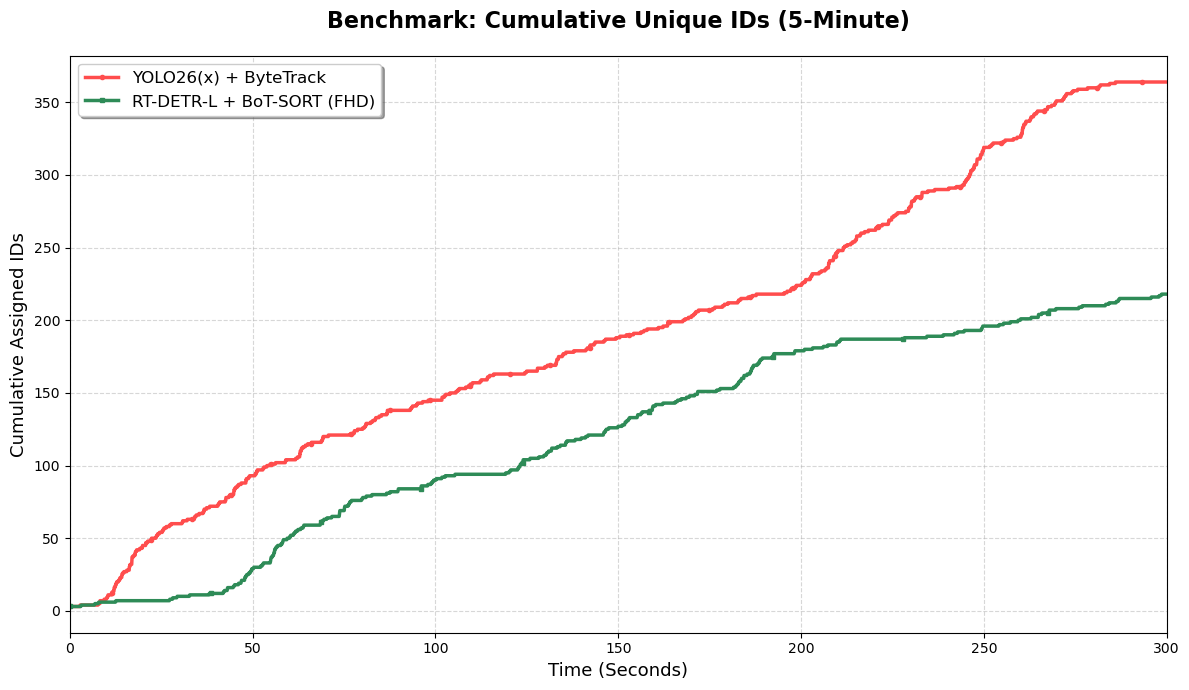

📈 최종 비교 그래프 'final_comparison_graph.png'가 생성되었습니다.


In [13]:
import matplotlib.pyplot as plt
import json
import os

# 데이터 로드
with open("tracking_history_v2.json", "r") as f:
    data = json.load(f)

plt.figure(figsize=(12, 7))

# 스타일 설정
styles = {
    "YOLO26_ByteTrack": {"color": "#ff4d4d", "label": "YOLO26(x) + ByteTrack", "marker": "o"},
    "RTDETR_BoTSORT": {"color": "#2e8b57", "label": "RT-DETR-L + BoT-SORT (FHD)", "marker": "s"}
}

for name, content in data.items():
    plt.plot(
        content["time"], 
        content["count"], 
        color=styles[name]["color"], 
        label=styles[name]["label"],
        linewidth=2.5,
        marker=styles[name]["marker"],
        markersize=3,
        markevery=300
    )

# 그래프 디테일
plt.title('Benchmark: Cumulative Unique IDs (5-Minute)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Time (Seconds)', fontsize=13)
plt.ylabel('Cumulative Assigned IDs', fontsize=13)
plt.xlim(0, 300)
plt.legend(loc='upper left', fontsize=12, shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# 이미지 저장
plt.savefig('final_comparison_graph.png', dpi=300)
plt.show()
print("📈 최종 비교 그래프 'final_comparison_graph.png'가 생성되었습니다.")

결론 : RT-DETR-L에서 bytetrack을 사용해도 더 좋았는데, bot-sort사용하니 더 좋다 !`

저장한 영상으로 할 경우 프레임이 더 잘나온다고 하길래 다운받아봤습니다.

In [ ]:
import cv2
import yt_dlp

url = 'https://www.youtube.com/watch?v=gIjrcfxcyoA'
ydl_opts = {"format": "bestvideo[height<=720]", "noplaylist": True}

with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    info = ydl.extract_info(url, download=False)
    stream_url = info.get('url') or info.get('formats')[0].get('url')

cap = cv2.VideoCapture(stream_url)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
# 720p 기준으로 저장 (해상도가 다르면 아래 숫자를 수정해야 할 수 있음)
out = cv2.VideoWriter('test_video.mp4', fourcc, 30.0, (1280, 720))

print("🎥 영상 저장 시작 (약 10초 소요)...")
frame_count = 0
while frame_count < 3000: # 30fps 기준 100초 = 3000프레임
    ret, frame = cap.read()
    if not ret: break
    
    # 혹시 원본 사이즈가 1280x720이 아니면 강제로 맞춤
    frame = cv2.resize(frame, (1280, 720))
    out.write(frame)
    frame_count += 1

cap.release()
out.release()
print("✅ test_video.mp4 저장 완료!")

[youtube] Extracting URL: https://www.youtube.com/watch?v=gIjrcfxcyoA
[youtube] gIjrcfxcyoA: Downloading webpage


[youtube] gIjrcfxcyoA: Downloading android vr player API JSON
🎥 영상 저장 시작 (약 10초 소요)...
✅ test_video.mp4 저장 완료!


In [ ]:
##%pip install tensorrt

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metada

[5] RTDETR에서 X모델과 L모델 비교 

X모델이 더 무거운 모델 (1080p) (최종 평균 속도: 12.4 FPS)

L모델이 기본 모델 (720p)

화질이 낮을 수록 FPS는 올라가지만, 멀리 있는걸 object tracking을 잘 못 함 


640으로 만들 경우 평균 프레임 : TensorRT 가속 평균 23.4 FPS

1280 고정

In [ ]:
from ultralytics import RTDETR

# 1. 원본 파이토치 모델 다시 로드
model = RTDETR("rtdetr-l.pt")

print("🚀 1280 고해상도 TensorRT 엔진 변환 시작! (시간이 꽤 걸립니다)")

# 2. imgsz를 1280으로 설정하여 새로운 엔진 파일 생성
# 파일명이 겹치지 않게 이름을 다르게 지정해 줍니다.
## 밑의 주석을 푸십시오.
## model.export(format="engine", device="0", half=True, imgsz=1280)

print("✅ 변환 완료! 'rtdetr-l.engine' (1280용) 준비 끝!")

🚀 1280 고해상도 TensorRT 엔진 변환 시작! (시간이 꽤 걸립니다)
Ultralytics 8.4.13  Python-3.11.14 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
rt-detr-l summary: 294 layers, 32,148,140 parameters, 0 gradients, 103.8 GFLOPs

PyTorch: starting from 'rtdetr-l.pt' with input shape (1, 3, 1280, 1280) BCHW and output shape(s) (1, 300, 84) (63.4 MB)

ONNX: starting export with onnx 1.20.1 opset 17...
ONNX: slimming with onnxslim 0.1.85...
ONNX: export success  15.2s, saved as 'rtdetr-l.onnx' (127.3 MB)

TensorRT: starting export with TensorRT 10.15.1.29...
TensorRT: input "images" with shape(1, 3, 1280, 1280) DataType.FLOAT
TensorRT: output "output0" with shape(1, 300, 84) DataType.FLOAT
TensorRT: building FP16 engine as rtdetr-l.engine
TensorRT: export success  273.1s, saved as 'rtdetr-l.engine' (67.6 MB)

Export complete (274.7s)
Results saved to C:\Users\wornj\KDT_10SL\Final_project_v2
Predict:         yolo predict task=detect model=rtdetr-l.engine imgsz=1280 half
Validate:        yolo va

In [ ]:
import cv2
import torch
import time
from ultralytics import RTDETR # 박스 깨짐 방지를 위해 RTDETR 사용

# [1] 정확도 최우선 설정
MODEL_PATH = "rtdetr-l.engine" 
TRACKER = "botsort.yaml" # 끈질긴 추적을 위해 BoT-SORT 유지
IMGSZ = 1280
VIDEO_PATH = "test_video.mp4"

model = RTDETR(MODEL_PATH) 
cap = cv2.VideoCapture(VIDEO_PATH)

window_name = "RTX 4070 - Accuracy First (BoT-SORT)"
cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)

print("🔥 프레임보다 정확도! 극강의 추적 안정성 모드로 시작합니다.")

frame_count = 0
total_time = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break

    start_time = time.time()
    
    # 🎯 놓치지 않기 위한 세밀한 파라미터 튜닝
    results = model.track(
        frame, 
        tracker=TRACKER, 
        imgsz=IMGSZ, 
        persist=True,
        conf=0.25,      # 신뢰도가 25%만 넘어도 (가려지거나 흐릿해도) 일단 추적 유지
        iou=0.45,       # 박스가 겹칠 때 동일 객체로 판단하는 기준을 여유롭게 설정
        classes=[2, 3, 5, 7], # 자동차, 오토바이, 버스, 트럭만 타겟팅
        verbose=False
    )
    
    inference_time = time.time() - start_time
    total_time += inference_time
    frame_count += 1

    # 결과 렌더링
    annotated_frame = results[0].plot()
    
    # FPS 표시
    current_fps = 1.0 / inference_time
    cv2.putText(annotated_frame, f"TRT+BoT-SORT FPS: {current_fps:.1f}", (20, 50), 
                cv2.FONT_HERSHEY_DUPLEX, 1.2, (0, 255, 0), 3)

    cv2.imshow(window_name, annotated_frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
for i in range(5):
    cv2.waitKey(1)

print(f"🏁 최종 결과: 극강 추적 모드 평균 {frame_count / total_time:.1f} FPS")
## 이게 프레임이 낮게 나오는데 밑에 X모델 같은 경우는 화면을 안 띄어서 높게 나온거다 원래 이렇게 낮게 나옴..

🔥 프레임보다 정확도! 극강의 추적 안정성 모드로 시작합니다.
Loading rtdetr-l.engine for TensorRT inference...
🏁 최종 결과: 극강 추적 모드 평균 4.8 FPS


젤 좋은 모델을 구축해보자  rtdetr-x + 1920x1080 모델

극한의 결과물 저장 완료! (최종 평균 속도: 12.4 FPS)

In [ ]:
from ultralytics import RTDETR

model = RTDETR("rtdetr-x.pt") # 원본 파이토치 모델 로드

print("🚀 1920x1080 직사각형 전용 엔진 변환 시작...")
# 🎯 핵심: imgsz를 [세로, 가로] 형태의 리스트로 정확히 지정합니다!
## 밑의 주석을 푸십시오.
## model.export(format="engine", device="0", half=True, imgsz=[1080, 1920])


🚀 1920x1080 직사각형 전용 엔진 변환 시작...
Ultralytics 8.4.13  Python-3.11.14 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
WARNING imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
rt-detr-x summary: 362 layers, 65,631,836 parameters, 0 gradients, 222.8 GFLOPs

PyTorch: starting from 'rtdetr-x.pt' with input shape (1, 3, 1088, 1920) BCHW and output shape(s) (1, 300, 84) (129.5 MB)

ONNX: starting export with onnx 1.20.1 opset 17...
ONNX: slimming with onnxslim 0.1.85...
ONNX: export success  23.2s, saved as 'rtdetr-x.onnx' (256.7 MB)

TensorRT: starting export with TensorRT 10.15.1.29...
TensorRT: input "images" with shape(1, 3, 1088, 1920) DataType.FLOAT
TensorRT: output "output0" with shape(1, 300, 84) DataType.FLOAT
TensorRT: building FP16 engine as rtdetr-x.engine
TensorRT: export success  396.2s, saved as 'rtdetr-x.engine' (149.4 MB)

Export complete (397.7s)
Results saved to C:\Users\wornj\KDT_10SL\Final_project_v2
Predict:         yolo predi

In [15]:
import cv2
import time  # 🎯 FPS 계산을 위해 time 모듈 추가
from ultralytics import RTDETR

# [1] 극한 설정
MODEL_PATH = "rtdetr-x.engine" # 1920 전용 가장 무거운 엔진
TRACKER = "botsort.yaml"      # 끈질긴 추적
IMGSZ = [1080, 1920]       # 1920 해상도 통째로 입력
VIDEO_PATH = "test_video.mp4"
OUTPUT_PATH = "final_result_extreme_1920p.mp4"

# 엔진 로드
model = RTDETR(MODEL_PATH)
cap = cv2.VideoCapture(VIDEO_PATH)

# 🎯 출력 영상 규격 설정
width = 1920
height = 1080
fps_out = 30.0  # 변수명 충돌 방지를 위해 fps_out으로 변경
fourcc = cv2.VideoWriter_fourcc(*'avc1')
out = cv2.VideoWriter(OUTPUT_PATH, fourcc, fps_out, (width, height))

# 화면 창 설정
window_name = "Extreme Accuracy 1920p with FPS"
cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)

print(f"🔥 [극한 모드] RT-DETR-X + BoT-SORT + 1920p 추론 시작...")
print("🐢 화면 왼쪽 위에 실시간 FPS가 표시됩니다!")

frame_count = 0
total_time = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break
    
    # ⏱️ 시간 측정 시작
    start_time = time.time()
    
    # 1. 입력 영상을 1920x1080으로 맞춤
    frame_1080p = cv2.resize(frame, (width, height))

    # 2. 추론
    results = model.track(
        frame_1080p,
        tracker=TRACKER,
        imgsz=IMGSZ,
        persist=True,
        conf=0.15, 
        iou=0.5,
        classes=[2, 3, 5, 7],
        verbose=False
    )

    # ⏱️ 추론 소요 시간 및 FPS 계산
    inference_time = time.time() - start_time
    total_time += inference_time
    current_fps = 1.0 / inference_time

    # 3. 결과 그리기
    annotated_frame = results[0].plot()
    
    # 🎯 화면에 FPS 글씨 쾅 박아넣기 (빨간색, 굵게)
    cv2.putText(annotated_frame, f"Extreme FPS: {current_fps:.1f}", (30, 70), 
                cv2.FONT_HERSHEY_DUPLEX, 1.5, (0, 0, 255), 3)
    
    # 4. 파일에 저장
    out.write(annotated_frame)
    
    # 5. 화면 출력
    cv2.imshow(window_name, annotated_frame)
    
    frame_count += 1
    if frame_count % 10 == 0:
        print(f"처리 중... {frame_count} 프레임 완료 (현재 평균: {frame_count / total_time:.1f} FPS)")

    if cv2.waitKey(1) & 0xFF == ord('q'):
        print("🛑 사용자에 의해 중단되었습니다.")
        break

cap.release()
out.release()
cv2.destroyAllWindows()
for i in range(5):
    cv2.waitKey(1)

if total_time > 0:
    print(f"✅ 극한의 결과물 저장 완료! (최종 평균 속도: {frame_count / total_time:.1f} FPS)")

🔥 [극한 모드] RT-DETR-X + BoT-SORT + 1920p 추론 시작...
🐢 화면 왼쪽 위에 실시간 FPS가 표시됩니다!
Loading rtdetr-x.engine for TensorRT inference...
WARNING imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
처리 중... 10 프레임 완료 (현재 평균: 6.6 FPS)
WARNING imgsz=[1080, 1920] must be multiple of max stride

L이랑 X 비교해볼까 

In [ ]:
import cv2
import time
import pandas as pd
from ultralytics import RTDETR

def extract_tracking_data(engine_path, imgsz_setting, output_csv):
    model = RTDETR(engine_path)
    cap = cv2.VideoCapture("test_video.mp4")
    
    unique_ids = set()
    log_data = [] # [시간(초), 누적 ID 수] 저장
    
    print(f"🚀 [{engine_path}] 데이터 추출 시작...")
    start_time = time.time()
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        
        # 입력 영상 강제 1080p 세팅
        frame = cv2.resize(frame, (1920, 1080))
        
        # 추론
        results = model.track(frame, tracker="botsort.yaml", imgsz=imgsz_setting, persist=True, conf=0.15, verbose=False)
        
        # 화면에 잡힌 객체들의 ID를 추출하여 중복 없이 저장
        if results[0].boxes is not None and results[0].boxes.id is not None:
            current_ids = results[0].boxes.id.cpu().numpy().tolist()
            unique_ids.update(current_ids)
            
        elapsed_time = time.time() - start_time
        log_data.append([elapsed_time, len(unique_ids)])
        
    cap.release()
    
    # 데이터를 CSV 파일로 저장
    df = pd.DataFrame(log_data, columns=['Time_Seconds', 'Cumulative_IDs'])
    df.to_csv(output_csv, index=False)
    print(f"✅ 데이터 저장 완료: {output_csv}")

# ---------------------------------------------------------
# 🎯 실행 방법: 아래 두 줄을 순서대로 하나씩 주석을 풀고 실행하세요.
# (VRAM이 터질 수 있으니 한 번에 하나씩만 돌리는 것을 권장합니다.)

# 1. L 모델 (640 엔진) 데이터 뽑기
##extract_tracking_data("rtdetr-l.engine", 1280, "log_640.csv")

# 2. X 모델 (1920 직사각형 엔진) 데이터 뽑기
##extract_tracking_data("rtdetr-x.engine", [1080, 1920], "log_1920.csv")

🚀 [rtdetr-x.engine] 데이터 추출 시작...
Loading rtdetr-x.engine for TensorRT inference...
WARNING imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING imgsz=[1080, 1920] must be multiple of 

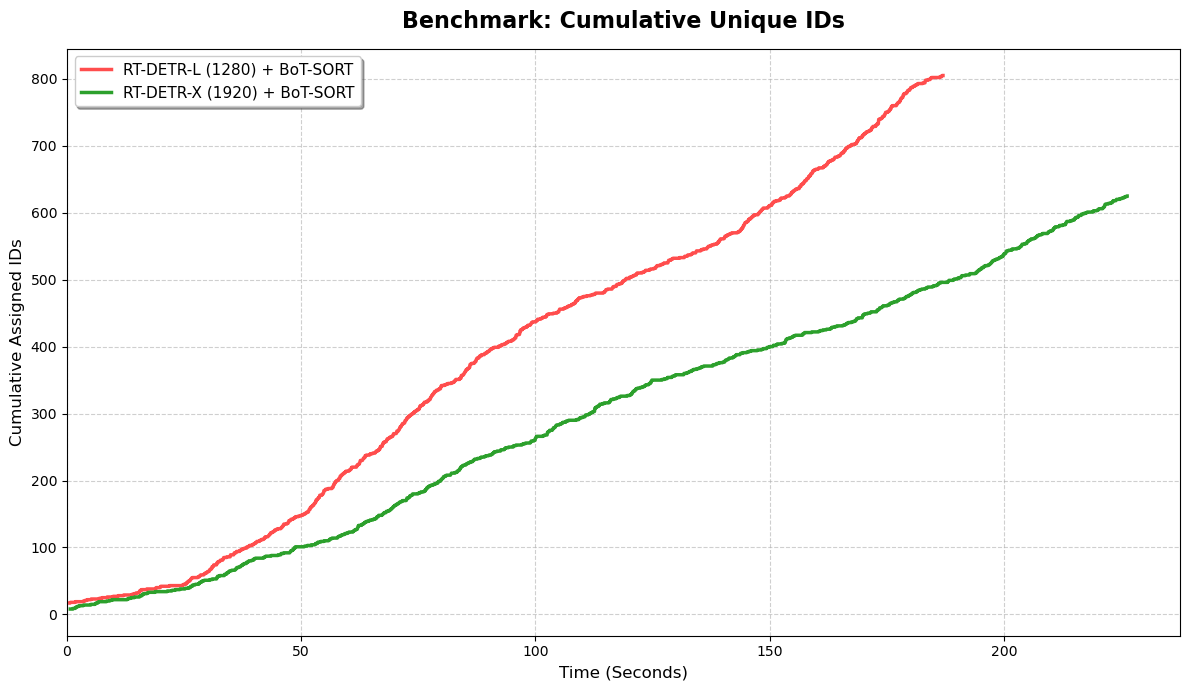

✅ 'benchmark_result.png' 파일이 저장되었습니다!


In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 불러오기
try:
    df_640 = pd.read_csv("log_640.csv")
    df_1920 = pd.read_csv("log_1920.csv")
except FileNotFoundError:
    print("❌ CSV 파일을 찾을 수 없습니다. 1단계 코드부터 실행해 주세요.")
    exit()

# 그래프 설정
plt.figure(figsize=(12, 7))

# 640 엔진 그래프 (붉은색 계열)
plt.plot(df_640['Time_Seconds'], df_640['Cumulative_IDs'], 
         label='RT-DETR-L (1280) + BoT-SORT', color='#ff4d4d', linewidth=2.5)

# 1920 엔진 그래프 (녹색 계열)
plt.plot(df_1920['Time_Seconds'], df_1920['Cumulative_IDs'], 
         label='RT-DETR-X (1920) + BoT-SORT', color='#2ca02c', linewidth=2.5)

# 꾸미기 (올려주신 사진 스타일 반영)
plt.title('Benchmark: Cumulative Unique IDs', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Time (Seconds)', fontsize=12)
plt.ylabel('Cumulative Assigned IDs', fontsize=12)
plt.xlim(left=0) # x축을 0부터 시작
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', shadow=True, fontsize=11)

# 그래프 파일로 저장 및 화면에 띄우기
plt.tight_layout()
plt.savefig('benchmark_result.png', dpi=300)
plt.show()

print("✅ 'benchmark_result.png' 파일이 저장되었습니다!")

FPS는 L이 평균 23 X가 12정도 나와 10정도 프레임 차이를 보여줬지만 
X모델이 더욱 잘 잡았다